In [1]:
from IPython.display import HTML

# Toggle butten to hide the code from the notebook
HTML('''<script>
code_show=true;
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
}
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# 1. Dataset

## 1.1 Dataset Description

In [58]:
df_raw = pd.read_csv("../files/early_diabetes_data.csv")
df_raw

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


The dataset used in this study consists of **520 patient records**, each observed on a set of physiological factors that is maybe associated with diabetes. The outcome variable, class, indicates whether a patient is categorized as Positive (early diabetic) or Negative (non-diabetic).

The dataset contains one continuous variable (Age) and 15 categorical predictor variables, each describing the presence or absence of a clinical condition or symptom. These variables include polyuria, polydipsia, sudden weight loss, weakness, polyphagia, partial paresis, and others that are known early clinical indicators of diabetes. Categorical variables are encoded using binary values (“Yes”/“No” or “Male”/“Female”).

The dataset was also collected from Syllhet Diabetes Hospital, Syllhet, Bangladesh

## 1.2 Data Wrangling

Since there were no missing values in the dataset, there was no data cleaning conducted. However, since the categorical variables were in string format, the values were encoded into 0s and 1s. Specifically, 1 for 'Female', 'Positive', or 'Yes'; and 0 for 'Male', 'Negative', or 'No'.

In [101]:
df_factored = df_raw.copy()

# flags for boolean indexing of columns
yn_flag = (df_raw.columns != "Age") & (df_raw.columns != "class") & (df_raw.columns != "Gender")
pred_flag = df_raw.columns != "class"

# Encoding Gender and class variables
df_factored["Gender"] = df_raw["Gender"].map(lambda x: 1 if x == "Female" else 0)
df_factored["class"] = df_raw["class"].map(lambda x: 1 if x == "Positive" else 0)

# encoding categorical variables(yes/no variables) in 0s and 1s
for col in df_raw.columns[yn_flag]:
    df_factored[col] = df_raw[col].map(lambda x: 1 if x == "Yes" else 0)

df_factored.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


# 2. Analysis

In [105]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis = 1).copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

## 2.1 Which symptoms are most strongly associated with diabetes, and why might these relationships exist?

To measure the association of the symptoms with diabetes, we shall use the difference in conditional probabilities. The difference in conditional probabilities measures how much more frequently a physiological factor occurs in diabetic patients compared to non-diabetic patients. Larger positive differences indicate stronger associations with diabetes, suggesting that these factors are more discriminative for identifying the disease.

In [73]:
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)

cat_features = df.drop(columns=['Age', 'age_group']).copy()
age = df['Age'].copy()

cat_features = np.transpose(cat_features.groupby('class').mean())
cat_features.columns = ['Negative', 'Positive']
cat_features['Difference'] = cat_features['Positive'] - cat_features['Negative']

cat_features.sort_values(by='Difference', ascending=False, inplace=True)
cat_features['Factors'] = cat_features.index
cat_features.reset_index(drop=True, inplace=True)

cat_features

,Negative,Positive,Difference,Factors
0,0.075,0.759375,0.684375,Polyuria
1,0.040,0.703125,0.663125,Polydipsia
2,0.095,0.540625,0.445625,Gender
3,0.145,0.587500,0.442500,sudden weight loss
4,0.160,0.600000,0.440000,partial paresis
5,0.240,0.590625,0.350625,Polyphagia
6,0.080,0.343750,0.263750,Irritability
7,0.290,0.546875,0.256875,visual blurring
8,0.435,0.681250,0.246250,weakness
9,0.300,0.421875,0.121875,muscle stiffness


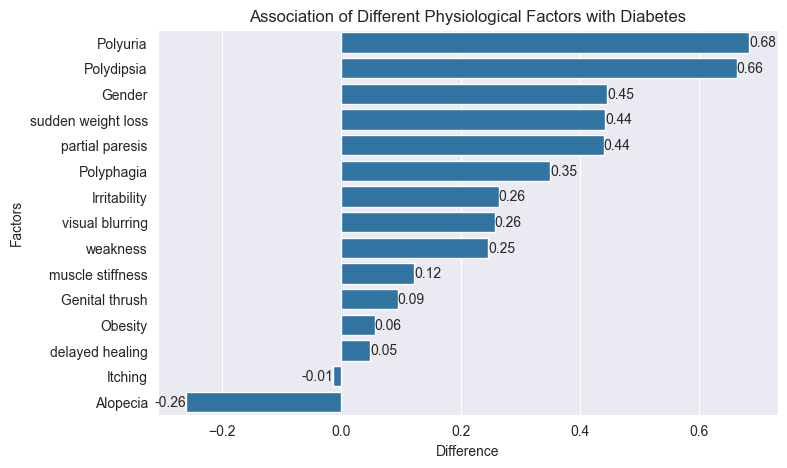

In [75]:
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=cat_features, y='Factors', x='Difference', ax=ax)

ax.set_xlabel('Difference')
ax.set_title('Association of Different Physiological Factors with Diabetes')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

From the graph above, it shows that both Polyuria and Polydipsia have the highest association with Diabetes with a difference in conditional probabilities of 0.68 and 0.66, respectively. These symptoms arise due to osmotic diuresis, where excess glucose in the blood leads to increased urine production and subsequent dehydration (American Diabetes Association, 2023). Similarly, polyphagia and weight loss occur because the body cannot effectively utilize glucose, leading to increased hunger and breakdown of fat and muscle for energy (Mayo Clinic, 2023).

## 2.2 Can a small subset of symptoms explains most diabetes cases, and what does this suggest about early detection?

## 2.3 How does age influence the presence of diabetes?

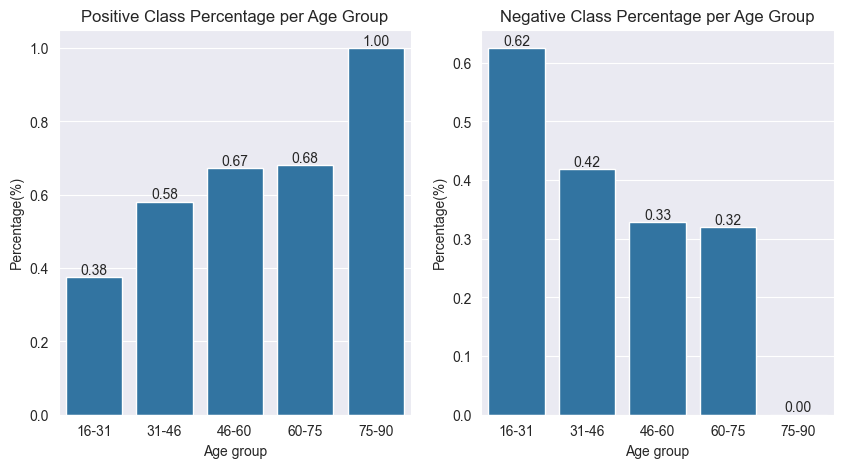

In [94]:
min_val = np.min(df['Age'].astype(int))
max_val = np.max(df['Age'].astype(int))

n_bins = 5
bins = np.linspace(min_val, max_val, n_bins + 1)
bins = np.round(bins).astype(int)

bins = np.unique(bins)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df["Age group"] = pd.cut(df['Age'], bins=bins, labels=bin_labels, include_lowest=True)

labels = ['Age group', 'class']
sliced = df.loc[:,labels]

new_labels = ['Age group', 'Positive', 'Negative']

diabetes_per_df = sliced.groupby('Age group').mean().reset_index()
diabetes_per_df['Negative'] = 1 - diabetes_per_df['class']
diabetes_per_df.columns = new_labels

fig, axs = plt.subplots(1,2,figsize=(10,5))

for idx, ax in enumerate(axs.flat):
    occur = ['Positive', 'Negative']

    sns.barplot(data=diabetes_per_df, x = 'Age group', y = occur[idx], ax=ax)
    ax.set_ylabel('Percentage(%)')
    ax.set_title(f'{occur[idx]} Class Percentage per Age Group')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

-> explain how there's an increasing trend in diabetes the older the patients get, percentage gets higher. However, the group 75-90 does not have a lot of patients. We shall try percentiles.

## 2.4 Are there distinct groups of patients based on symptoms, and do these groups differ in diabetes outcomes?

In [108]:
df = df_factored.copy()

target = df['class']
features = df.drop('class', axis=1).copy()

To determine the groups of patients, we shall use K-means clustering to determine the clusters of patients. Furthermore, we shall use silhouette score as a metric to determine the optimal number of clusters such that each patient in each cluster has a high similarity with other patients within the same cluster.

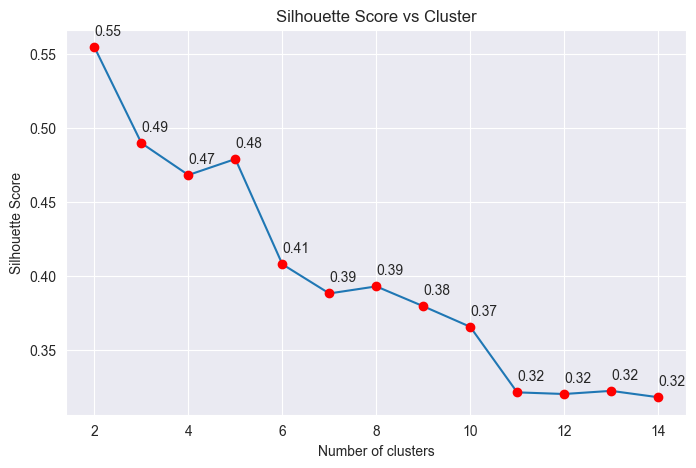

In [109]:
clusters = [i for i in range(2, 15)]
silhouettes = {
    'Cluster' : [],
    'Score': []
}

for cluster in clusters:
    kmeans = KMeans(n_clusters=cluster, random_state=0)
    label = kmeans.fit_predict(df)
    silhouettes['Score'].append(silhouette_score(df, label))
    silhouettes['Cluster'].append(cluster)

silhouettes = pd.DataFrame(silhouettes)

fig, ax = plt.subplots(figsize=(8,5))
sns.lineplot(data=silhouettes, x='Cluster', y='Score', ax=ax)
plt.plot(silhouettes['Cluster'], silhouettes['Score'], 'ro')

for x, y in zip(silhouettes['Cluster'], silhouettes['Score']):
    ax.text(x, y + 0.008, f"{y:.2f}")


plt.title("Silhouette Score vs Cluster")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

After an analysis on the optimal number of cluster on the dataset using K-means clustering technique, we have arrived at an optimal cluster of 2 with a silhouette score of ~0.55. Now, we do an analysis of the features of each cluster.

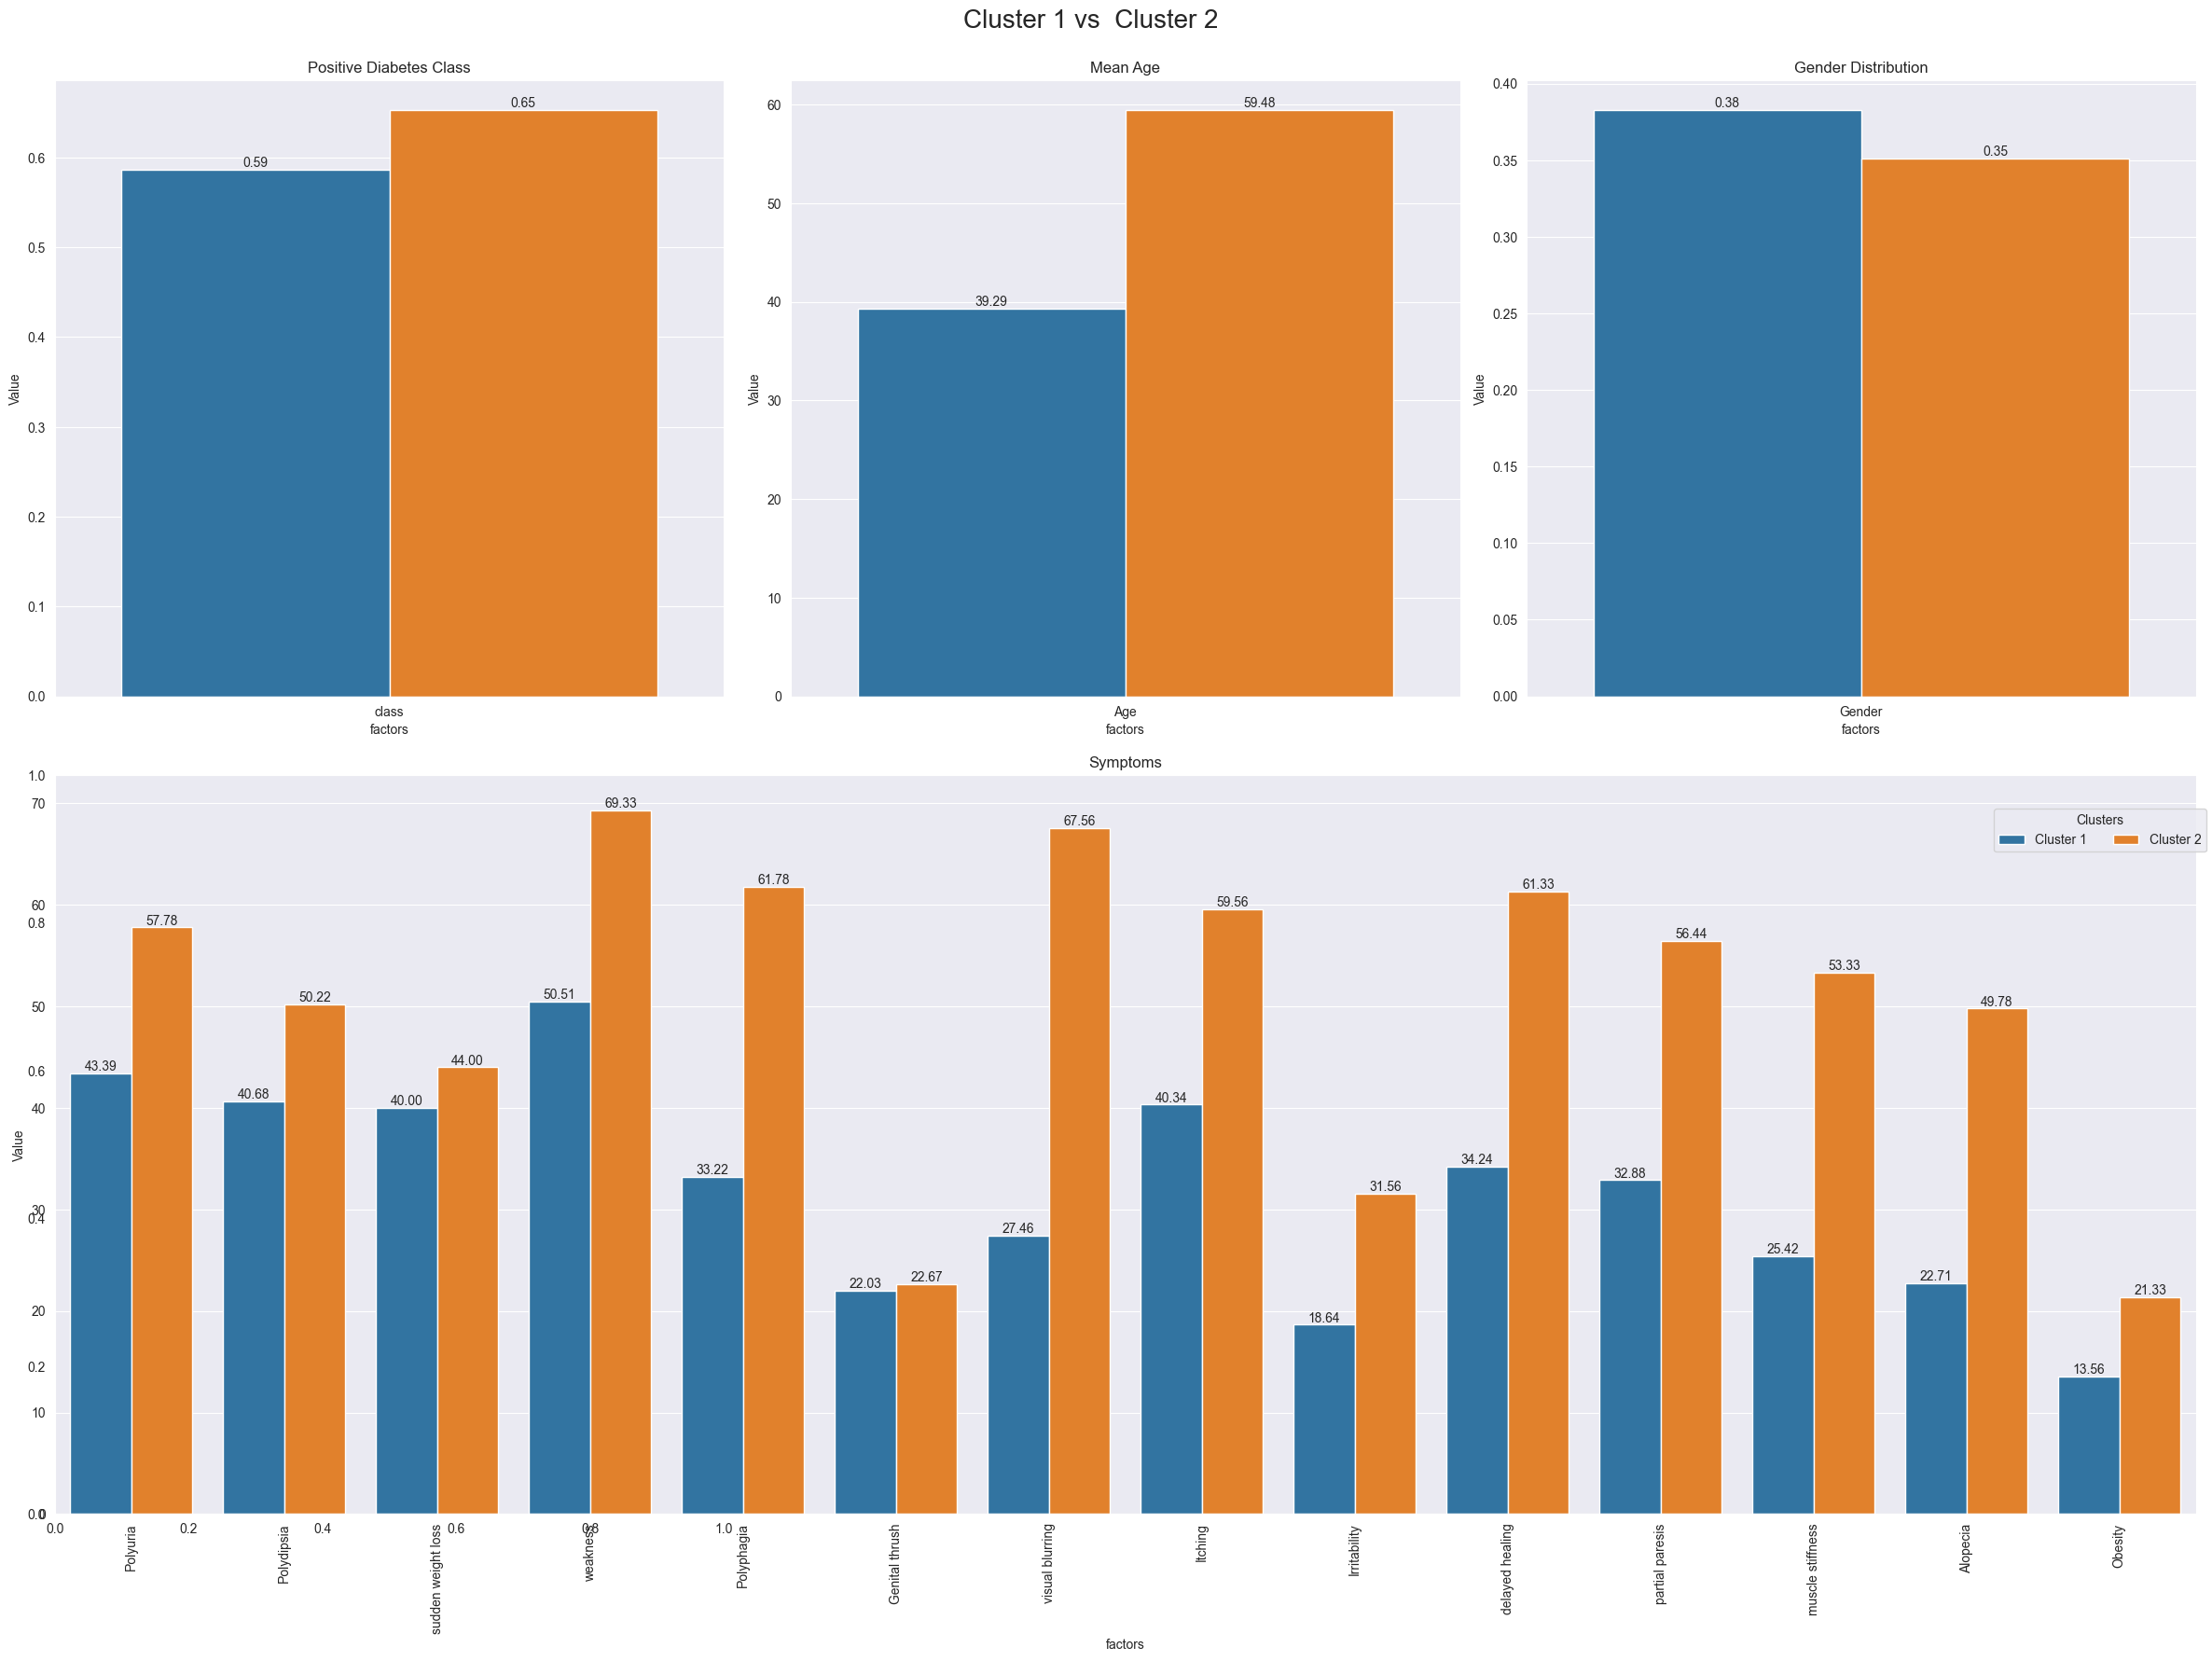

In [110]:
optimal_cluster = silhouettes.loc[silhouettes['Score'].idxmax(), 'Cluster']

kmeans = KMeans(n_clusters=optimal_cluster, random_state=0)
label = kmeans.fit_predict(df)
df_clustered = df.copy()
df_clustered['cluster'] = label
clustered_mean = df_clustered.groupby('cluster').mean().copy()
clustered_mean = np.transpose(clustered_mean).copy()
clustered_mean['factors'] = clustered_mean.index
clustered_mean = clustered_mean.reset_index(drop=True)
clustered_mean.columns = ['Cluster 1', 'Cluster 2', 'factors']

combined = clustered_mean.melt(
    id_vars="factors",
    value_vars=["Cluster 1", "Cluster 2"],
    var_name="Class",
    value_name="Value"
)

categorical_factors = combined.loc[combined['factors'] != 'Age', :].loc[combined['factors'] != 'Gender', :].loc[combined['factors'] != 'class', :]
age = combined.loc[combined['factors'] == 'Age', :]
gender = combined.loc[combined['factors'] == 'Gender', :]
diabetes_class = combined.loc[combined['factors'] == 'class', :]

categorical_factors['Value'] = categorical_factors['Value']*100

fig = plt.figure(figsize=(24, 18))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.2])

ax0 = fig.add_subplot(gs[0, 0])
sns.barplot(data=diabetes_class, x='factors', y='Value', hue='Class', ax=ax0)
ax0.set_title('Positive Diabetes Class')
ax1 = fig.add_subplot(gs[1, 0])

ax1 = fig.add_subplot(gs[0, 1])
sns.barplot(data=age, x='factors', y='Value', hue='Class', ax=ax1)
ax1.set_title('Mean Age')

ax2 = fig.add_subplot(gs[0, 2])
sns.barplot(data=gender, x='factors', y='Value', hue='Class', ax=ax2)
ax2.set_title('Gender Distribution')

ax3 = fig.add_subplot(gs[1, :])
sns.barplot(data=categorical_factors, x='factors', y='Value', hue='Class', ax=ax3)
ax3.set_title('Symptoms')
ax3.tick_params(axis='x', rotation=90)

for ax in [ax0, ax1, ax2, ax3]:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

for ax in [ax0, ax1, ax2, ax3]:
    ax.legend_.remove()

handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, title='Clusters', loc='center right', ncol=2)

fig.suptitle('Cluster 1 vs  Cluster 2', y=1, fontsize=20)
plt.tight_layout()
plt.show()

Since the mean of binary coded variables(0 and 1) is just the percentage of one of the values, we refer to the mean of binary categorical variables as percentage. Furthermore,

According to the graphs above, we can see that Cluster 1 observes a low average generally among all factors except for gender compared to Cluster 2. Cluster 1 has less positive diabetes cases with a percentage of 59% in contrast with the 65% of Cluster 2. Cluster 1 holds a younger set of patients evident by the lower mean age of 39.29 while Cluster 2 has an older set of patients with a mean of 59.48. This is a significant difference of ~20 years. In this dataset, there is a higher distribution of Male patients. This is also true for both clusters. However, Cluster 2 has a higher percentage of women than Cluster 2 with the percentage being 38% and 35% respectively. Lastly, Cluster 2 observes a higher percentage of its patients experiencing these symptoms compared to cluster 1.

 To summarize, Cluster 1 is characterized by a younger set of patients, lower occurrence of diabetes, and also fewer patients experiencing the symptoms. This might be a result of an overall younger set of patients. Since younger patients have a relatively stronger vitality, higher resilience, and a stronger immune system, it may explain the lower presence of symptoms among the patients in the cluster. Additionally, women are more physiologically more resilient than men which may add to the lower symptom presence. In contrast, Cluster 2 is characterized by an older set of patients, higher occurrence of diabetes, and also fewer patients experiencing the symptoms.

With this, each cluster differ in diabetes outcome. Cluster 1 has 59% of its patients with diabetes and Cluster 2 has 65% of its patents with diabetes. As mentioned above, this difference may be a result of physiological differences like age differences and gender differences.

# References

American Diabetes Association. (n.d.). Diabetes symptoms.
https://diabetes.org/about-diabetes/warning-signs-symptoms

Mayo Clinic. (2026). Diabetes - Symptoms and causes.
https://www.mayoclinic.org/diseases-conditions/diabetes/symptoms-causes/syc-20371444